In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
original_dataset_dir = r"C:\Users\pk\Desktop\class"

In [7]:
import os

original_dataset_dir = '/content/drive/MyDrive/class'
print("Folder exists?", os.path.exists(original_dataset_dir))
print("Contents:", os.listdir(original_dataset_dir))

Folder exists? True
Contents: ['Uveal Melanoma (UM)', 'Normal']


In [8]:
classes = os.listdir(original_dataset_dir)
print(classes)

['Uveal Melanoma (UM)', 'Normal']


In [9]:
for cls in classes:
    class_dir = os.path.join(original_dataset_dir, cls)
    num_images = len(os.listdir(class_dir))
    print(f"Class: {cls} --> {num_images} images")

Class: Uveal Melanoma (UM) --> 85 images
Class: Normal --> 1354 images


In [12]:
import os
import shutil
import numpy as np

# 1 Original dataset path
original_dataset_dir = '/content/drive/MyDrive/class'  # aapke Drive me folder ka path

# 2 Split dataset base folder
base_dir = '/content/drive/MyDrive/class_split'
os.makedirs(base_dir, exist_ok=True)

subdirs = ['train', 'val', 'test']
classes = ['Uveal Melanoma (UM)', 'Normal']

# 3 Create folder structure
for subdir in subdirs:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, subdir, cls), exist_ok=True)

# 4 Split ratio
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# 5 Split images
for cls in classes:
    class_dir = os.path.join(original_dataset_dir, cls)

    # List images
    images = os.listdir(class_dir)
    np.random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # Copy images
    for img in train_images:
        shutil.copy(os.path.join(class_dir, img), os.path.join(base_dir, 'train', cls, img))
    for img in val_images:
        shutil.copy(os.path.join(class_dir, img), os.path.join(base_dir, 'val', cls, img))
    for img in test_images:
        shutil.copy(os.path.join(class_dir, img), os.path.join(base_dir, 'test', cls, img))

print(" Dataset split complete!")

 Dataset split complete!


In [13]:
import os
print(os.listdir('/content/drive/MyDrive/class_split'))


['train', 'val', 'test']


In [14]:
for subdir in subdirs:
    print(f"\n{subdir.upper()} SET:")
    for cls in classes:
        folder = os.path.join(base_dir, subdir, cls)
        print(f"{cls}: {len(os.listdir(folder))} images")


TRAIN SET:
Uveal Melanoma (UM): 59 images
Normal: 947 images

VAL SET:
Uveal Melanoma (UM): 12 images
Normal: 203 images

TEST SET:
Uveal Melanoma (UM): 14 images
Normal: 204 images


In [17]:
train_um_dir = '/content/drive/MyDrive/class_split/train/Uveal Melanoma (UM)'
images = os.listdir(train_um_dir)
print(f"Current UM images: {len(images)}")

Current UM images: 59


In [20]:
import os
import random
from PIL import Image
from torchvision import transforms

train_um_dir = '/content/drive/MyDrive/class_split/train/Uveal Melanoma (UM)'
target_count = 1000

images = os.listdir(train_um_dir)
current_count = len(images)
print(f"Current UM images: {current_count}")

augment = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

i = 0
while current_count < target_count:
    img_name = random.choice(images)
    img_path = os.path.join(train_um_dir, img_name)

    img = Image.open(img_path).convert('RGB')
    aug_img = augment(img)

    # Save augmented image with safe name
    save_name = f"aug_UM_{i}.jpg"
    save_path = os.path.join(train_um_dir, save_name)
    aug_img.save(save_path)

    current_count += 1
    i += 1

print(f"Augmentation complete! Total UM images now: {len(os.listdir(train_um_dir))}")

Current UM images: 59
Augmentation complete! Total UM images now: 1000


In [22]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Training transforms (augmentation already done for UM, can add basic transforms)
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

train_dataset = datasets.ImageFolder('/content/drive/MyDrive/class_split/train', transform=train_transforms)
val_dataset   = datasets.ImageFolder('/content/drive/MyDrive/class_split/val', transform=val_test_transforms)
test_dataset  = datasets.ImageFolder('/content/drive/MyDrive/class_split/test', transform=val_test_transforms)


# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [23]:
import torch
import torch.nn as nn
from torchvision import models

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load pretrained ResNet50
model = models.resnet50(pretrained=True)

# Replace final layer for 2 classes (UM vs Normal)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 115MB/s]


In [24]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [25]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct.double() / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

Epoch 1/10 - Loss: 0.1025 - Accuracy: 0.9615
Epoch 2/10 - Loss: 0.0125 - Accuracy: 0.9959
Epoch 3/10 - Loss: 0.0013 - Accuracy: 1.0000
Epoch 4/10 - Loss: 0.0006 - Accuracy: 1.0000
Epoch 5/10 - Loss: 0.0003 - Accuracy: 1.0000
Epoch 6/10 - Loss: 0.0002 - Accuracy: 1.0000
Epoch 7/10 - Loss: 0.0001 - Accuracy: 1.0000
Epoch 8/10 - Loss: 0.0001 - Accuracy: 1.0000
Epoch 9/10 - Loss: 0.0001 - Accuracy: 1.0000
Epoch 10/10 - Loss: 0.0001 - Accuracy: 1.0000


In [26]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)
        total += labels.size(0)

print(f"Test Accuracy: {correct.double()/total:.4f}")

Test Accuracy: 0.9862


In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import torch


# Make sure model is in eval mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# Print classification report
report = classification_report(all_labels, all_preds, target_names=classes)
print("Classification Report:\n", report)

# Confusion matrix (optional)
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

Classification Report:
                      precision    recall  f1-score   support

Uveal Melanoma (UM)       0.99      1.00      0.99       204
             Normal       1.00      0.79      0.88        14

           accuracy                           0.99       218
          macro avg       0.99      0.89      0.94       218
       weighted avg       0.99      0.99      0.99       218

Confusion Matrix:
 [[204   0]
 [  3  11]]


In [29]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np

# --- Paths ---
test_dir = '/content/drive/MyDrive/class_split/test'

# --- Transforms ---
test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

# --- Dataset & Loader ---
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --- Load your trained model ---
# Example: model = torch.load('model.pth')
# Make sure model is in eval mode
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- Get class names in correct order ---
classes = test_dataset.classes  # This ensures labels match folder names
print("Class order:", classes)

# --- Confusion Matrix & Report ---
cm = confusion_matrix(all_labels, all_preds)
report = classification_report(all_labels, all_preds, target_names=classes)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

Class order: ['Normal', 'Uveal Melanoma (UM)']
Confusion Matrix:
 [[204   0]
 [  3  11]]

Classification Report:
                      precision    recall  f1-score   support

             Normal       0.99      1.00      0.99       204
Uveal Melanoma (UM)       1.00      0.79      0.88        14

           accuracy                           0.99       218
          macro avg       0.99      0.89      0.94       218
       weighted avg       0.99      0.99      0.99       218



In [30]:
import torch

# Assume model trained ho chuka hai
model_path = "/content/drive/MyDrive/uveal_model_weights.pth"
torch.save(model.state_dict(), model_path)
print("Model weights saved!")

Model weights saved!


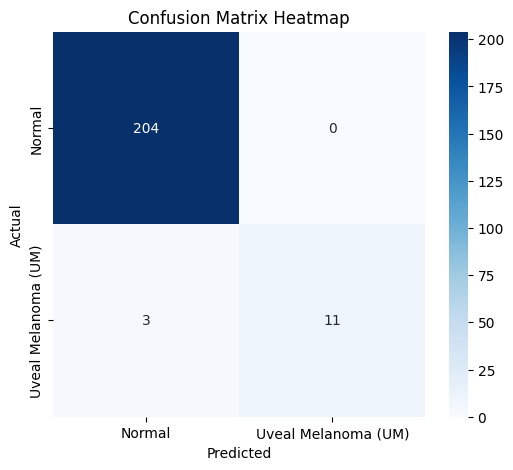

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Suppose all_labels aur all_preds already available
# classes = test_dataset.classes  # ['Normal', 'Uveal Melanoma (UM)']

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()